# using linear regression 
baseline

finds one equation connecting the inputs to cashflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
data_path = Path("../data/raw_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3265, 16)


,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   project_id              3265 non-null   str    
 1   project_type            3265 non-null   str    
 2   project_scale           3265 non-null   str    
 3   project_duration_years  3265 non-null   int64  
 4   complexity_index        3265 non-null   float64
 5   initial_investment      3265 non-null   float64
 6   tax_rate                3265 non-null   float64
 7   risk_index              3265 non-null   float64
 8   year                    3265 non-null   int64  
 9   inflation_rate          3265 non-null   float64
 10  market_growth_rate      3265 non-null   float64
 11  revenue                 3265 non-null   float64
 12  operating_cost          3265 non-null   float64
 13  capex                   3265 non-null   float64
 14  working_capital         3265 non-null   float64
 15

In [6]:
df.isnull().sum()

project_id                0
project_type              0
project_scale             0
project_duration_years    0
complexity_index          0
initial_investment        0
tax_rate                  0
risk_index                0
year                      0
inflation_rate            0
market_growth_rate        0
revenue                   0
operating_cost            0
capex                     0
working_capital           0
cash_flow                 0
dtype: int64

In [7]:
print(df["cash_flow"].describe())

count    3.265000e+03
mean     7.256354e+06
std      1.001305e+07
min     -4.711468e+07
25%      1.681006e+06
50%      5.629000e+06
75%      1.168094e+07
max      7.532640e+07
Name: cash_flow, dtype: float64


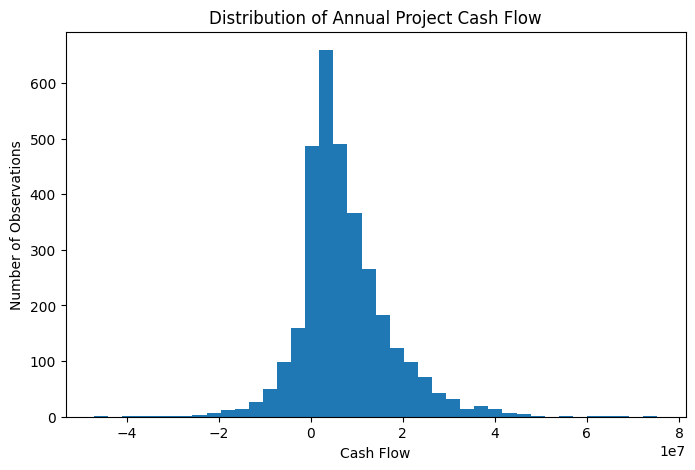

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["cash_flow"], bins=40)

plt.xlabel("Cash Flow")
plt.ylabel("Number of Observations")
plt.title("Distribution of Annual Project Cash Flow")

plt.show()

In [9]:
target = "cash_flow"

features = [
    "project_type",
    "project_scale",
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

X = df[features]
y = df[target]

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (3265, 10)
y shape: (3265,)

Features:
['project_type', 'project_scale', 'project_duration_years', 'complexity_index', 'initial_investment', 'tax_rate', 'risk_index', 'year', 'inflation_rate', 'market_growth_rate']

Target:
cash_flow


In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

In [25]:
train_df = df[df["project_id"].isin(train_projects)].copy()

test_df = df[df["project_id"].isin(test_projects)].copy()

In [26]:
print("Training projects:", train_df["project_id"].nunique())
print("Testing projects:", test_df["project_id"].nunique())

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training projects: 400
Testing projects: 100
Training rows: 2620
Testing rows: 645


In [27]:
print(
    "Projects appearing in both sets:",
    len(
        set(train_df["project_id"])
        & set(test_df["project_id"])
    )
)

Projects appearing in both sets: 0


In [28]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [29]:
categorical_features = [
    "project_type",
    "project_scale"
]

numerical_features = [
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [31]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]
)

In [32]:
linear_regression_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [33]:
y_pred = linear_regression_model.predict(X_test)

In [34]:
comparison = pd.DataFrame({
    "actual_cash_flow": y_test.values,
    "predicted_cash_flow": y_pred
})

comparison.head(10)

,actual_cash_flow,predicted_cash_flow
0,-2395752.07,-8.568033e+04
1,5588259.78,1.904218e+06
2,3249734.67,3.858777e+06
3,8667076.68,6.025372e+06
4,9068670.71,8.231586e+06
5,10906457.69,9.859531e+06
6,7209321.18,1.173913e+07
7,10192767.52,1.336993e+07
8,10402911.22,1.557472e+07
9,1625496.13,-3.991988e+06


In [35]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [36]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

In [38]:
r2 = r2_score(
    y_test,
    y_pred
)

In [39]:
print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹5,687,745.42
RMSE: ₹8,201,915.20
R²:   0.2915


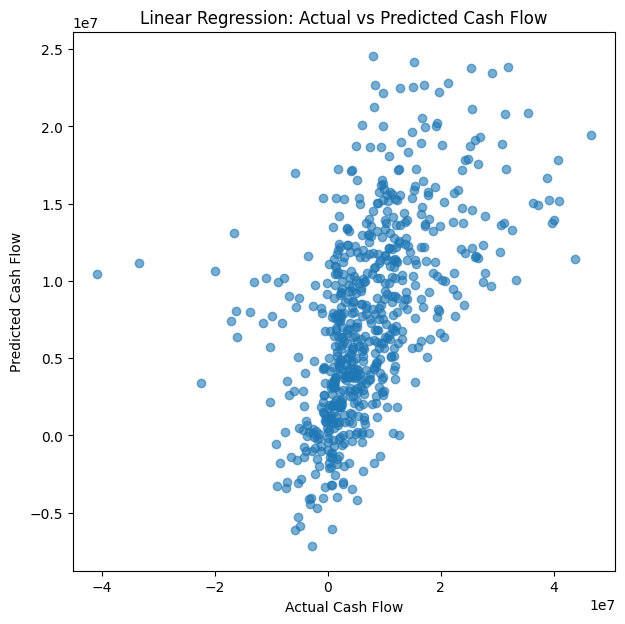

In [40]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("Linear Regression: Actual vs Predicted Cash Flow")

plt.show()

In [41]:
residuals = y_test.values - y_pred

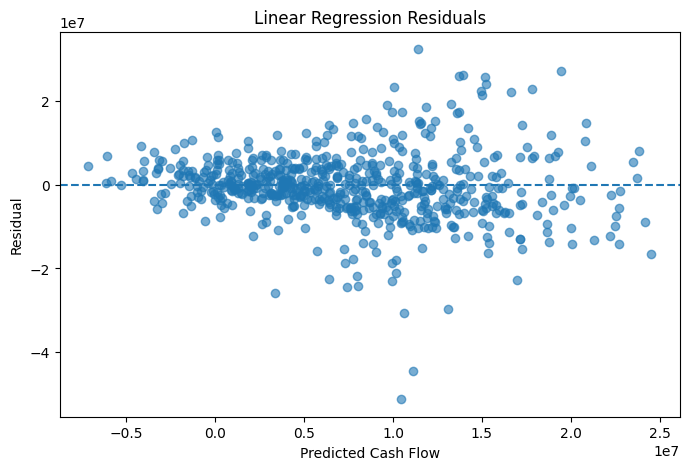

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Cash Flow")
plt.ylabel("Residual")
plt.title("Linear Regression Residuals")

plt.show()

what the model actually learned

In [43]:
model = linear_regression_model.named_steps["model"]
# preprocessing steps
preprocessor_fitted = (
    linear_regression_model
    .named_steps["preprocessing"]
)
# the features
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

# getting coeffiecients and sorting them
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_
})
coefficients = coefficients.sort_values(
    "coefficient",
    ascending=False
)

coefficients

,feature,coefficient
16,numerical__market_growth_rate,7.210542e+06
5,categorical__project_type_Technology,3.136761e+06
0,categorical__project_type_Energy,2.372562e+06
14,numerical__year,1.881027e+06
4,categorical__project_type_Real Estate,1.354156e+06
7,categorical__project_scale_Medium,6.605592e+05
1,categorical__project_type_Healthcare,3.302035e+05
13,numerical__risk_index,2.439761e+05
11,numerical__initial_investment,6.355794e-02
8,categorical__project_scale_Small,-1.386485e+05


results 

In [44]:
results = {
    "model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

results

{'model': 'Linear Regression',
 'MAE': 5687745.4220670685,
 'RMSE': np.float64(8201915.20072865),
 'R2': 0.29153501590805275}